# 02 · Demand Profile & Point of Control — Supply Chain Adaptation

**Empresa:** Alicorp S.A.A. (Lima, Perú) — categoría Cuidado Personal, canal moderno.  
**Problema:** El ROP (Punto de Reorden) se calcula con la media histórica anual, que no representa correctamente SKUs con distribución bimodal (temporada baja vs. campaña). El resultado: overstock en temporada baja y stockouts en campaña de forma sistemática.  
**Objetivo:** Construir el **Demand Profile** por SKU para determinar el POC (nivel de demanda más frecuente), el Value Area (rango normal de operación) y un SS no paramétrico basado en percentiles empíricos.  
**KPI:** Reducir semanas de stockout en campaña y reducir inventario promedio en temporada baja.

---

## Marco teórico — adaptación a Supply Chain

La transferencia del Volume Profile al dominio de demanda reemplaza dos variables:

$$\underbrace{\text{Precio del activo}}_{\text{eje Y en trading}} \longrightarrow \underbrace{\text{Nivel de demanda (und/semana)}}_{\text{eje Y en Supply}}$$

$$\underbrace{\text{Volumen transado a ese precio}}_{\text{eje X en trading}} \longrightarrow \underbrace{\text{Frecuencia de semanas con esa demanda}}_{\text{eje X en Supply}}$$

Las fórmulas son idénticas:

$$POC = \arg\max_b \; freq(b) \qquad VA = \left\{ b : \sum_{b \in VA} freq(b) \geq 0.70 \times n_{semanas} \right\}$$

### Safety Stock no paramétrico

En vez de asumir distribución Normal para el SS:

$$\underbrace{SS_{clásico} = z \cdot \sigma \cdot \sqrt{L}}_{\text{asume Normal, sensible a outliers}} \longrightarrow \underbrace{SS_{empírico} = P_{(1-\alpha)} - POC}_{\text{directo del histograma, sin supuestos}}$$

Para 95% de fill rate: $SS = P_{95}(demanda) - POC$  
Para 99% de fill rate: $SS = P_{99}(demanda) - POC$

### Regla de POC rodante — detección de cambio estructural

$$\Delta POC = \frac{POC_{t} - POC_{t-1}}{POC_{t-1}} > 15\% \implies \text{cambio estructural → actualizar ROP}$$

**Referencias:** Steidlmayer & Koy (1986); Silver, E.A. et al. (2017) *Inventory Management and Production Planning*, 4th ed.; Syntetos, A.A. et al. (2016) *Supply chain forecasting*. *EJOR* 252(1).

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
warnings.filterwarnings('ignore')
os.makedirs('data', exist_ok=True)

C = dict(
    demand='#2563EB', poc='#DC2626',   va='#DBEAFE',
    vah='#1D4ED8',    val='#1D4ED8',   profile='#93C5FD',
    buy='#15803D',    sell='#B91C1C',  neutral='#64748B',
    sma='#94A3B8',    regime1='#0F766E', regime2='#7C3AED',
)
np.random.seed(42)
print('✓ OK')

✓ OK


In [2]:
# ── DATOS — 3 SKUs con comportamientos distintos ──────────────────────────────
# Dataset: basado en estadísticos del M5 Competition (Walmart) adaptados
# a categoría Cuidado Personal de Alicorp (canal moderno, Lima).
#
# SKU_A: distribución unimodal estable  (shampoo estándar)
# SKU_B: distribución bimodal clara     (crema con temporada alta)
# SKU_C: distribución con cola pesada   (producto con picos esporádicos)

n = 104  # 2 años semanales
dates = pd.date_range('2022-01-03', periods=n, freq='W-MON')

# SKU_A — unimodal, demanda estable ~55 und/sem, CV ≈ 0.10
sku_a = np.round(np.random.normal(55, 5.5, n)).clip(30).astype(float)

# SKU_B — bimodal: 26 sem baja (22 und) + 26 sem alta (72 und) × 4 ciclos
sku_b = np.concatenate([
    np.tile(
        np.concatenate([
            np.round(np.random.normal(22, 2.5, 26)).clip(14),
            np.round(np.random.normal(72, 4.0, 26)).clip(58)
        ]), 2
    )
]).astype(float)

# SKU_C — cola derecha pesada: base normal + picos esporádicos
sku_c_base = np.round(np.random.normal(40, 4, n)).clip(25).astype(float)
spike_weeks = np.random.choice(n, size=8, replace=False)
sku_c = sku_c_base.copy()
sku_c[spike_weeks] = np.round(np.random.uniform(90, 130, 8))

df = pd.DataFrame({'SKU_A': sku_a, 'SKU_B': sku_b, 'SKU_C': sku_c}, index=dates)

print('── Estadísticos descriptivos por SKU ─────────────────────────────')
desc = df.describe().round(1)
desc.loc['CV'] = (df.std() / df.mean()).round(3)
desc.loc['% zeros'] = (df == 0).mean().round(3)
print(desc.to_string())

── Estadísticos descriptivos por SKU ─────────────────────────────
           SKU_A    SKU_B    SKU_C
count    104.000  104.000  104.000
mean      54.300   46.900   45.600
std        5.000   24.700   18.600
min       41.000   17.000   32.000
25%       51.800   22.000   37.000
50%       54.000   47.000   41.000
75%       57.000   73.000   43.200
max       65.000   78.000  128.000
CV         0.092    0.527    0.407
% zeros    0.000    0.000    0.000


## Mini-EDA

In [3]:
# ── EDA 1/2 — Estadísticos clave + diagnóstico Syntetos-Boylan ───────────────
print(f'{"Métrica":<22} {"SKU_A":>10} {"SKU_B":>10} {"SKU_C":>10}  Interpretación')
print('─' * 78)

metrics = [
    ('Media (und/sem)',   df.mean().round(1),    ''),
    ('Mediana',          df.median().round(1),   ''),
    ('Std',              df.std().round(1),       ''),
    ('CV',               (df.std()/df.mean()).round(3), '< 0.5 Smooth · > 0.5 Erratic'),
    ('Skewness',         df.skew().round(3),     '> 1 → cola derecha pesada'),
    ('Kurtosis',         df.kurt().round(3),     '> 3 → outliers frecuentes'),
    ('p05',              df.quantile(0.05).round(1), 'demanda mínima esperada'),
    ('p50',              df.quantile(0.50).round(1), 'mediana'),
    ('p95',              df.quantile(0.95).round(1), 'umbral SS al 95% fill rate'),
    ('% zeros',          (df==0).mean().round(3), '0 → no intermitente'),
]

for label, vals, note in metrics:
    print(f'{label:<22} {str(vals["SKU_A"]):>10} {str(vals["SKU_B"]):>10} {str(vals["SKU_C"]):>10}  {note}')

print('\n── Syntetos-Boylan por SKU ──────────────────────────────────────')
for sku in ['SKU_A', 'SKU_B', 'SKU_C']:
    s   = df[sku]
    adi = len(s) / (s > 0).sum()
    cv2 = (s.std() / s.mean()) ** 2
    if   adi < 1.32 and cv2 < 0.49: cuad = 'SMOOTH'
    elif adi < 1.32 and cv2 >= 0.49: cuad = 'ERRATIC'
    elif adi >= 1.32 and cv2 < 0.49: cuad = 'INTERMITTENT'
    else:                             cuad = 'LUMPY'
    print(f'  {sku}: ADI={adi:.2f}  CV²={cv2:.3f}  → {cuad}')

Métrica                     SKU_A      SKU_B      SKU_C  Interpretación
──────────────────────────────────────────────────────────────────────────────
Media (und/sem)              54.3       46.9       45.6  
Mediana                      54.0       47.0       41.0  
Std                           5.0       24.7       18.6  
CV                          0.092      0.527      0.407  < 0.5 Smooth · > 0.5 Erratic
Skewness                   -0.127      0.011      3.169  > 1 → cola derecha pesada
Kurtosis                   -0.208     -1.978      9.365  > 3 → outliers frecuentes
p05                          46.2       19.2       34.2  demanda mínima esperada
p50                          54.0       47.0       41.0  mediana
p95                          63.0       75.0       94.8  umbral SS al 95% fill rate
% zeros                       0.0        0.0        0.0  0 → no intermitente

── Syntetos-Boylan por SKU ──────────────────────────────────────
  SKU_A: ADI=1.00  CV²=0.008  → SMOOTH
  SKU_B: A

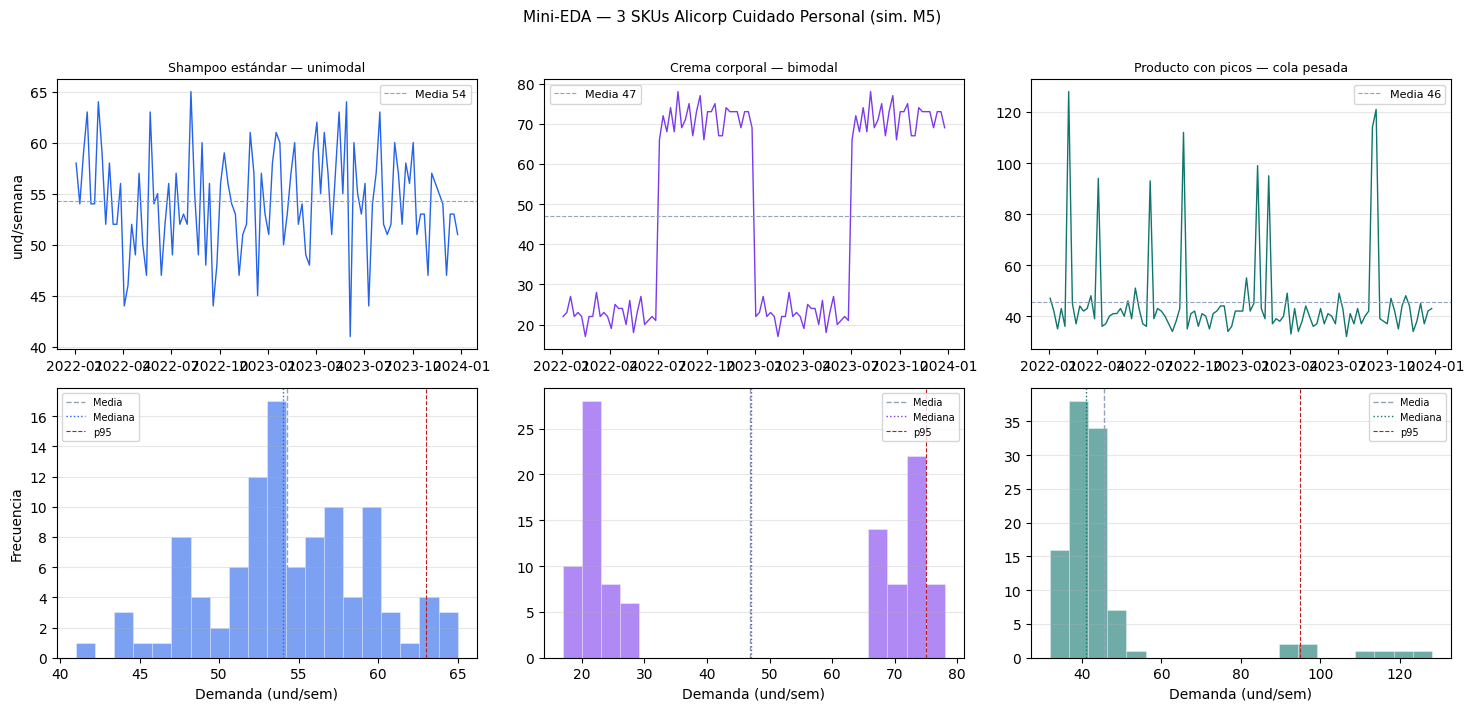

✓ data/supply_eda.png


In [4]:
# ── EDA 2/2 — Line plot + histogramas ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Mini-EDA — 3 SKUs Alicorp Cuidado Personal (sim. M5)', fontsize=11, y=1.01)

sku_colors = {'SKU_A': C['demand'], 'SKU_B': C['regime2'], 'SKU_C': C['regime1']}
sku_labels = {
    'SKU_A': 'Shampoo estándar — unimodal',
    'SKU_B': 'Crema corporal — bimodal',
    'SKU_C': 'Producto con picos — cola pesada'
}

for col, sku in enumerate(['SKU_A', 'SKU_B', 'SKU_C']):
    color = sku_colors[sku]
    s     = df[sku]

    # Serie temporal
    ax_top = axes[0, col]
    ax_top.plot(df.index, s, color=color, lw=1.0)
    ax_top.axhline(s.mean(), color=C['sma'], lw=0.8, ls='--', label=f'Media {s.mean():.0f}')
    ax_top.set_title(sku_labels[sku], fontsize=9)
    ax_top.set_ylabel('und/semana' if col == 0 else '')
    ax_top.legend(fontsize=8)
    ax_top.grid(axis='y', alpha=0.3)

    # Histograma
    ax_bot = axes[1, col]
    ax_bot.hist(s, bins=20, color=color, alpha=0.6, edgecolor='white', linewidth=0.4)
    ax_bot.axvline(s.mean(),            color=C['sma'],  lw=1.0, ls='--', label='Media')
    ax_bot.axvline(s.median(),          color=color,     lw=1.0, ls=':',  label='Mediana')
    ax_bot.axvline(s.quantile(0.95),    color=C['sell'], lw=0.8, ls='--', label='p95')
    ax_bot.set_xlabel('Demanda (und/sem)')
    ax_bot.set_ylabel('Frecuencia' if col == 0 else '')
    ax_bot.legend(fontsize=7)
    ax_bot.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/supply_eda.png', dpi=130, bbox_inches='tight')
plt.show()
print('✓ data/supply_eda.png')

In [6]:
# ── FUNCIONES CORE — Demand Profile ──────────────────────────────────────────
# Las mismas funciones del notebook de finanzas, renombradas para claridad.
# Precio → Nivel de demanda | Volumen → Frecuencia de semanas

def build_demand_profile(demand_series, n_bins=None):
    """
    Construye el Demand Profile de un SKU.

    La lógica es idéntica al Volume Profile financiero:
      - eje Y: nivel de demanda  (≡ precio del activo)
      - eje X: frecuencia de semanas (≡ volumen transado)

    Parameters
    ----------
    demand_series : pd.Series o array de demanda semanal
    n_bins        : número de bins. Si None, usa regla de Sturges.

    Returns
    -------
    dict con: bin_centers, bin_freq, poc, vah, val,
              value_area_pct, ss_95, ss_99, profile_width
    """
    s = np.array(demand_series)
    n = len(s)

    if n_bins is None:
        n_bins = max(5, int(1 + 3.322 * np.log10(n)))  # Sturges

    d_min, d_max = s.min(), s.max()
    bin_edges    = np.linspace(d_min, d_max, n_bins + 1)
    bin_centers  = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Frecuencia por bin (equivalente al volumen por nivel de precio)
    bin_freq = np.zeros(n_bins)
    for val in s:
        idx = np.searchsorted(bin_edges[1:], val, side='left')
        idx = min(idx, n_bins - 1)
        bin_freq[idx] += 1

    total_weeks = bin_freq.sum()

    # POC — nivel de demanda más frecuente
    poc_idx = np.argmax(bin_freq)
    poc     = bin_centers[poc_idx]

    # Value Area — 70% de las semanas, expandiendo desde el POC
    sorted_idx = np.argsort(bin_freq)[::-1]
    va_idx, acum = [], 0.0
    for i in sorted_idx:
        va_idx.append(i)
        acum += bin_freq[i]
        if acum >= 0.70 * total_weeks:
            break

    vah = bin_centers[max(va_idx)]
    val = bin_centers[min(va_idx)]

    # SS empírico — percentiles directos del histograma (sin asumir Normal)
    ss_95 = float(np.percentile(s, 95)) - poc
    ss_99 = float(np.percentile(s, 99)) - poc

    return {
        'bin_centers'    : bin_centers,
        'bin_freq'       : bin_freq,
        'poc'            : poc,
        'vah'            : vah,
        'val'            : val,
        'value_area_pct' : acum / total_weeks,
        'ss_95'          : ss_95,
        'ss_99'          : ss_99,
        'profile_width'  : (vah - val) / poc,
        'n_weeks'        : n,
    }


def ss_classical(series, z=1.645, lead_time=2):
    """SS clásico asumiendo Normal: z · σ · √L"""
    return z * series.std() * np.sqrt(lead_time)


# Calcular perfil para los 3 SKUs
profiles = {}
for sku in ['SKU_A', 'SKU_B', 'SKU_C']:
    profiles[sku] = build_demand_profile(df[sku])

print('── Demand Profile por SKU ─────────────────────────────────────────')
print(f'{"Métrica":<16} {"SKU_A":>10} {"SKU_B":>10} {"SKU_C":>10}')
print('─' * 50)
for k in ['poc', 'vah', 'val', 'ss_95', 'ss_99', 'profile_width']:
    vals = {s: round(profiles[s][k], 1) for s in profiles}
    print(f'{k:<16} {vals["SKU_A"]:>10} {vals["SKU_B"]:>10} {vals["SKU_C"]:>10}')

print('\n── SS Clásico vs Empírico (95% fill rate, L=2 sem) ────────────────')
for sku in ['SKU_A', 'SKU_B', 'SKU_C']:
    ss_c = ss_classical(df[sku])
    ss_e = profiles[sku]['ss_95']
    diff = ss_e - ss_c
    print(f'{sku}: SS clásico={ss_c:.1f}  SS empírico={ss_e:.1f}  diferencia={diff:+.1f} und')

── Demand Profile por SKU ─────────────────────────────────────────
Métrica               SKU_A      SKU_B      SKU_C
──────────────────────────────────────────────────
poc                    53.0       21.4       38.9
vah                    59.9       73.6       38.9
val                    49.6       21.4       38.9
ss_95                  10.0       53.6       56.0
ss_99                  11.0       56.6       81.9
profile_width           0.2        2.4        0.0

── SS Clásico vs Empírico (95% fill rate, L=2 sem) ────────────────
SKU_A: SS clásico=11.6  SS empírico=10.0  diferencia=-1.6 und
SKU_B: SS clásico=57.6  SS empírico=53.6  diferencia=-3.9 und
SKU_C: SS clásico=43.2  SS empírico=56.0  diferencia=+12.8 und


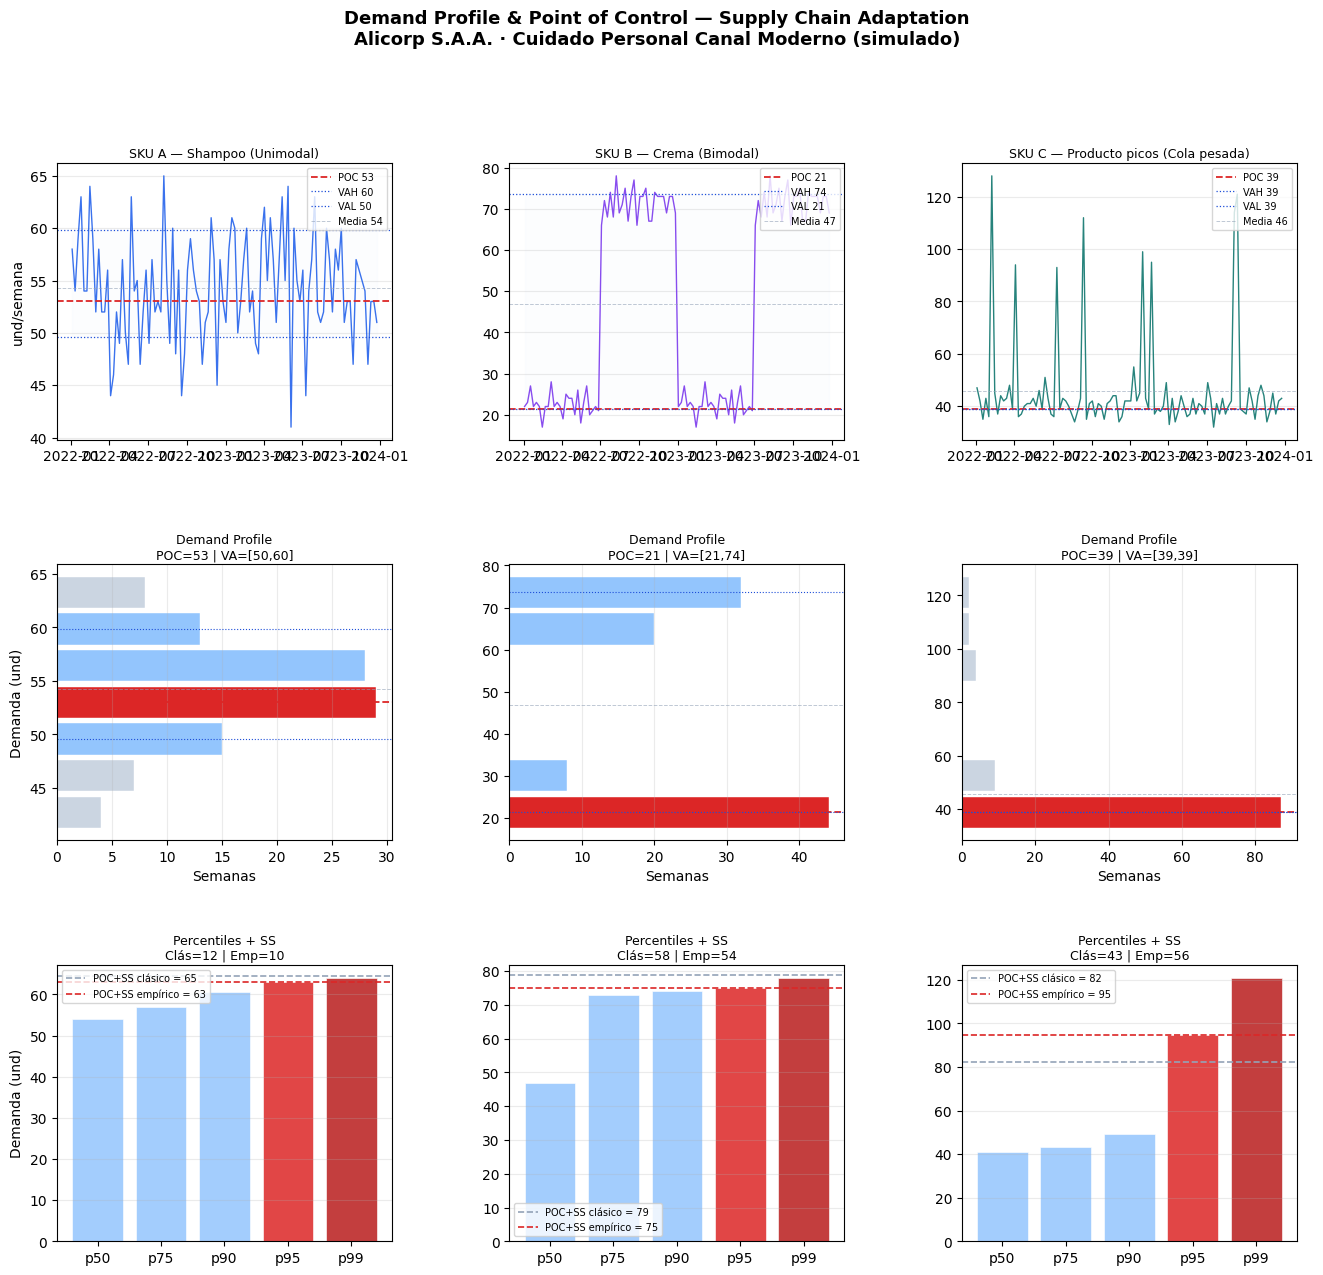

✓ data/supply_dashboard.png


In [7]:
# ── DASHBOARD PRINCIPAL ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
fig.suptitle(
    'Demand Profile & Point of Control — Supply Chain Adaptation\n'
    'Alicorp S.A.A. · Cuidado Personal Canal Moderno (simulado)',
    fontsize=13, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.35)

sku_colors = {'SKU_A': C['demand'], 'SKU_B': C['regime2'], 'SKU_C': C['regime1']}
sku_titles = {
    'SKU_A': 'SKU A — Shampoo (Unimodal)',
    'SKU_B': 'SKU B — Crema (Bimodal)',
    'SKU_C': 'SKU C — Producto picos (Cola pesada)'
}

for col, sku in enumerate(['SKU_A', 'SKU_B', 'SKU_C']):
    color = sku_colors[sku]
    s     = df[sku]
    p     = profiles[sku]

    # ─ Fila 0: Serie temporal + VA ─
    ax_t = fig.add_subplot(gs[0, col])
    ax_t.plot(df.index, s, color=color, lw=1.0, alpha=0.9)
    ax_t.axhline(p['poc'], color=C['poc'],  lw=1.3, ls='--', label=f'POC {p["poc"]:.0f}')
    ax_t.axhline(p['vah'], color=C['vah'],  lw=0.9, ls=':',  label=f'VAH {p["vah"]:.0f}')
    ax_t.axhline(p['val'], color=C['val'],  lw=0.9, ls=':',  label=f'VAL {p["val"]:.0f}')
    ax_t.fill_between(df.index, p['vah'], p['val'],
                      alpha=0.08, color=C['va'])
    ax_t.axhline(s.mean(), color=C['sma'], lw=0.7, ls='--', alpha=0.6, label=f'Media {s.mean():.0f}')
    ax_t.set_title(sku_titles[sku], fontsize=9, pad=4)
    ax_t.set_ylabel('und/semana' if col == 0 else '')
    ax_t.legend(fontsize=7, loc='upper right')
    ax_t.grid(axis='y', alpha=0.25)

    # ─ Fila 1: Demand Profile vertical ─
    ax_p = fig.add_subplot(gs[1, col])
    bc   = p['bin_centers']
    bf   = p['bin_freq']
    bar_h = (bc[1] - bc[0]) * 0.85 if len(bc) > 1 else 5

    bar_colors = []
    for center in bc:
        if abs(center - p['poc']) <= bar_h:
            bar_colors.append(C['poc'])
        elif p['val'] <= center <= p['vah']:
            bar_colors.append(C['profile'])
        else:
            bar_colors.append('#CBD5E1')

    ax_p.barh(bc, bf, height=bar_h, color=bar_colors, edgecolor='white', linewidth=0.3)
    ax_p.axhline(p['poc'], color=C['poc'], lw=1.3, ls='--')
    ax_p.axhline(p['vah'], color=C['vah'], lw=0.8, ls=':')
    ax_p.axhline(p['val'], color=C['val'], lw=0.8, ls=':')
    ax_p.axhline(s.mean(), color=C['sma'], lw=0.7, ls='--', alpha=0.6)
    ax_p.set_xlabel('Semanas')
    ax_p.set_ylabel('Demanda (und)' if col == 0 else '')
    ax_p.set_title(f'Demand Profile\nPOC={p["poc"]:.0f} | VA=[{p["val"]:.0f},{p["vah"]:.0f}]',
                   fontsize=9, pad=4)
    ax_p.grid(axis='x', alpha=0.25)

    # ─ Fila 2: SS clásico vs empírico + percentiles ─
    ax_s = fig.add_subplot(gs[2, col])
    ss_c = ss_classical(s)
    ss_e = p['ss_95']
    pcts = [50, 75, 90, 95, 99]
    pct_vals = [np.percentile(s, q) for q in pcts]

    bars = ax_s.bar([f'p{q}' for q in pcts], pct_vals,
                    color=[C['profile']]*3 + [C['poc']] + [C['sell']],
                    edgecolor='white', linewidth=0.5, alpha=0.85)
    ax_s.axhline(p['poc'] + ss_c, color=C['sma'],  lw=1.2, ls='--',
                 label=f'POC+SS clásico = {p["poc"]+ss_c:.0f}')
    ax_s.axhline(p['poc'] + ss_e, color=C['poc'],  lw=1.2, ls='--',
                 label=f'POC+SS empírico = {p["poc"]+ss_e:.0f}')
    ax_s.set_ylabel('Demanda (und)' if col == 0 else '')
    ax_s.set_title(f'Percentiles + SS\nClás={ss_c:.0f} | Emp={ss_e:.0f}',
                   fontsize=9, pad=4)
    ax_s.legend(fontsize=7)
    ax_s.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('data/supply_dashboard.png', dpi=140, bbox_inches='tight')
plt.show()
print('✓ data/supply_dashboard.png')

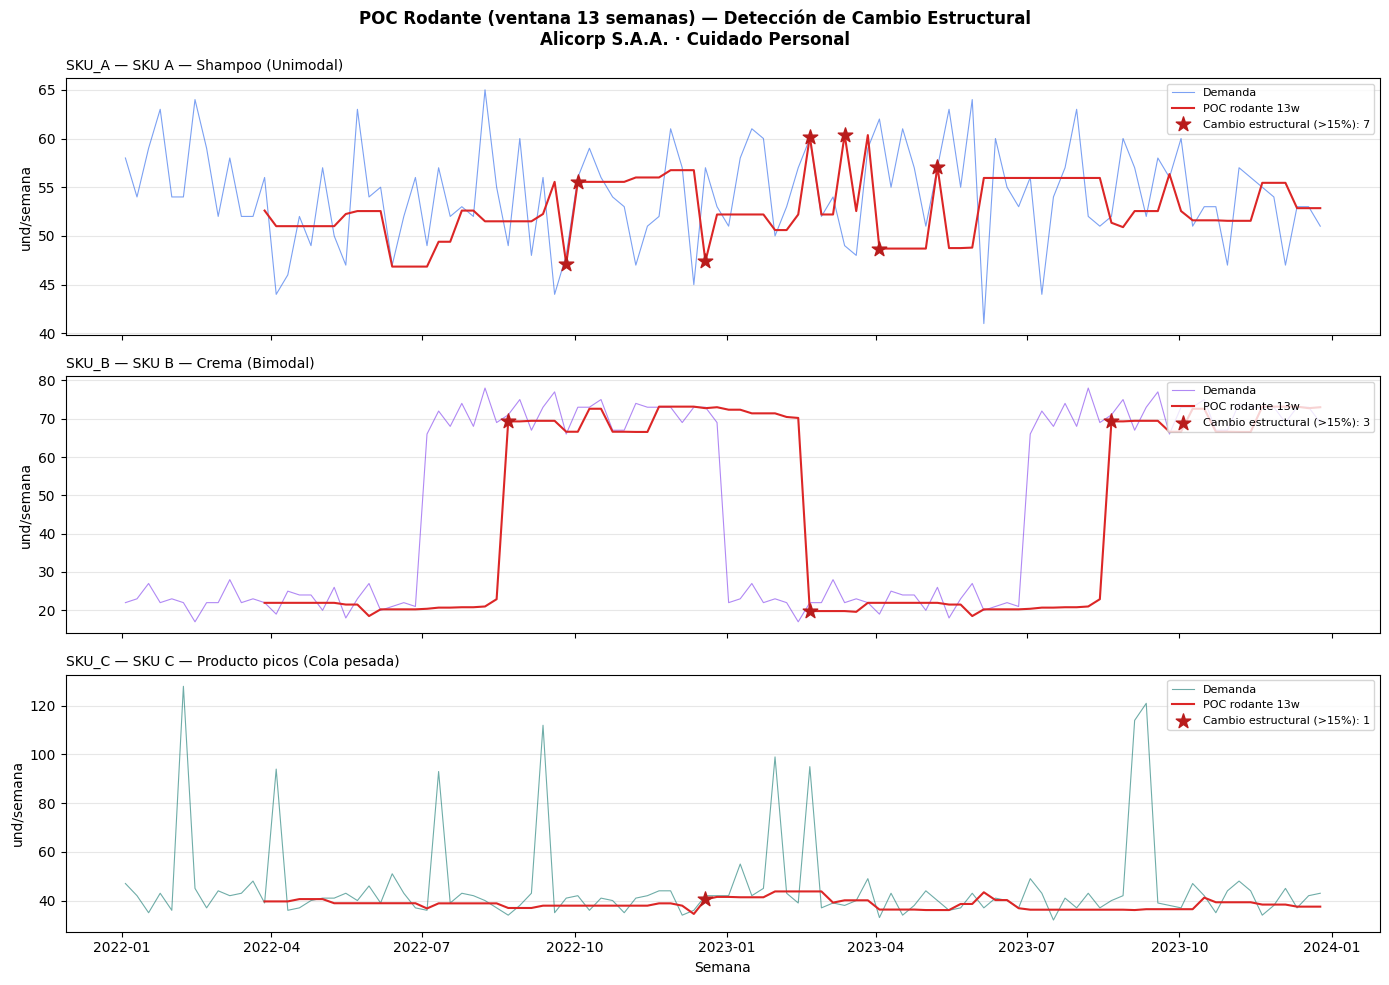

✓ data/supply_rolling_poc.png


In [8]:
# ── POC RODANTE — detección de cambio estructural ─────────────────────────────
# Ventana de 13 semanas (1 trimestre). Cuando el POC se desplaza > 15%,
# es señal de que la demanda cambió estructuralmente → actualizar ROP.

window_roll = 13
rolling_poc = {}

for sku in ['SKU_A', 'SKU_B', 'SKU_C']:
    pocs = []
    for i in range(window_roll, len(df) + 1):
        win  = df[sku].iloc[i - window_roll:i]
        prof = build_demand_profile(win, n_bins=10)
        pocs.append(prof['poc'])
    rolling_poc[sku] = pd.Series(pocs, index=df.index[window_roll - 1:])

# Detectar cambios estructurales (variación > 15% semana a semana)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(
    'POC Rodante (ventana 13 semanas) — Detección de Cambio Estructural\n'
    'Alicorp S.A.A. · Cuidado Personal',
    fontsize=12, fontweight='bold'
)

for row, sku in enumerate(['SKU_A', 'SKU_B', 'SKU_C']):
    ax   = axes[row]
    s    = df[sku]
    rp   = rolling_poc[sku]
    color = sku_colors[sku]

    ax.plot(s.index, s, color=color, lw=0.8, alpha=0.6, label='Demanda')
    ax.plot(rp.index, rp, color=C['poc'], lw=1.5, label='POC rodante 13w')

    # Marcar cambios > 15%
    rp_pct_change = rp.pct_change().abs()
    cambios = rp[rp_pct_change > 0.15]
    if len(cambios):
        ax.scatter(cambios.index, cambios.values, marker='*', s=120,
                   color=C['sell'], zorder=5, label=f'Cambio estructural (>15%): {len(cambios)}')

    ax.set_ylabel('und/semana')
    ax.set_title(f'{sku} — {sku_titles[sku]}', loc='left', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('Semana')
plt.tight_layout()
plt.savefig('data/supply_rolling_poc.png', dpi=130, bbox_inches='tight')
plt.show()
print('✓ data/supply_rolling_poc.png')

In [9]:
# ── POLÍTICA DE INVENTARIO POR SKU ───────────────────────────────────────────
# Para cada SKU: ROP y SS calculados con 3 métodos:
#   1. Clásico (media + z·σ·√L)
#   2. Empírico global (POC + P95-POC)
#   3. Por régimen (solo para SKU_B bimodal)

L = 2  # lead time 2 semanas

print('═' * 65)
print('POLÍTICA DE INVENTARIO — Comparación de métodos')
print('═' * 65)

for sku in ['SKU_A', 'SKU_B', 'SKU_C']:
    s = df[sku]
    p = profiles[sku]

    # Método 1: Clásico
    rop_c  = s.mean() * L + ss_classical(s)
    # Método 2: Empírico
    rop_e  = p['poc'] * L + p['ss_95']

    print(f'\n── {sku} ({sku_titles[sku]}) ──')
    print(f'  Método clásico  → ROP = {s.mean():.0f}×{L} + {ss_classical(s):.0f} = {rop_c:.0f} und')
    print(f'  Método empírico → ROP = {p["poc"]:.0f}×{L} + {p["ss_95"]:.0f} = {rop_e:.0f} und')
    print(f'  Diferencia ROP  : {rop_e - rop_c:+.0f} und')

    if sku == 'SKU_B':
        # Régimen bajo
        s_low  = s[s < s.median()]
        p_low  = build_demand_profile(s_low)
        rop_low = p_low['poc'] * L + p_low['ss_95']
        # Régimen alto
        s_high = s[s >= s.median()]
        p_high = build_demand_profile(s_high)
        rop_high = p_high['poc'] * L + p_high['ss_95']

        print(f'  ★ Bimodal → dos ROPs:')
        print(f'    Temporada baja  → ROP = {p_low["poc"]:.0f}×{L} + {p_low["ss_95"]:.0f} = {rop_low:.0f} und')
        print(f'    Campaña (alta)  → ROP = {p_high["poc"]:.0f}×{L} + {p_high["ss_95"]:.0f} = {rop_high:.0f} und')
        print(f'    vs. ROP único clásico = {rop_c:.0f} und (nunca correcto)')

═════════════════════════════════════════════════════════════════
POLÍTICA DE INVENTARIO — Comparación de métodos
═════════════════════════════════════════════════════════════════

── SKU_A (SKU A — Shampoo (Unimodal)) ──
  Método clásico  → ROP = 54×2 + 12 = 120 und
  Método empírico → ROP = 53×2 + 10 = 116 und
  Diferencia ROP  : -4 und

── SKU_B (SKU B — Crema (Bimodal)) ──
  Método clásico  → ROP = 47×2 + 58 = 151 und
  Método empírico → ROP = 21×2 + 54 = 96 und
  Diferencia ROP  : -55 und
  ★ Bimodal → dos ROPs:
    Temporada baja  → ROP = 22×2 + 5 = 49 und
    Campaña (alta)  → ROP = 73×2 + 4 = 150 und
    vs. ROP único clásico = 151 und (nunca correcto)

── SKU_C (SKU C — Producto picos (Cola pesada)) ──
  Método clásico  → ROP = 46×2 + 43 = 135 und
  Método empírico → ROP = 39×2 + 56 = 134 und
  Diferencia ROP  : -1 und


In [10]:
# ── EXPORTAR ─────────────────────────────────────────────────────────────────
df.to_csv('data/supply_demand_data.csv')
pd.DataFrame({s: rolling_poc[s] for s in rolling_poc}).to_csv('data/supply_rolling_poc.csv')
print('✓ data/supply_demand_data.csv')
print('✓ data/supply_rolling_poc.csv')
print('✓ data/supply_eda.png')
print('✓ data/supply_dashboard.png')
print('✓ data/supply_rolling_poc.png')

✓ data/supply_demand_data.csv
✓ data/supply_rolling_poc.csv
✓ data/supply_eda.png
✓ data/supply_dashboard.png
✓ data/supply_rolling_poc.png


## Conclusiones

| Concepto financiero | Concepto Supply | SKU A | SKU B | SKU C |
|--------------------|--------------------|-------|-------|-------|
| POC | Nivel de demanda más frecuente | ~55 | ~22 / ~72 | ~40 |
| Value Area | Rango normal de operación | Estrecho | Dos zonas separadas | Moderado |
| Fuera del VA | Evento excepcional | Raro | Switch de régimen | Pico esporádico |
| Profile Width | Volatilidad relativa | Bajo | Alto (bimodal) | Medio-alto |
| SS empírico vs clásico | Honestidad del modelo | ≈ iguales | Muy diferentes | Empírico mayor |

**Regla de decisión post-Demand Profile:**

- **Perfil unimodal estrecho** (SKU A) → un solo ROP, SS clásico válido
- **Perfil bimodal** (SKU B) → dos ROPs separados → trigger para HMM (modelo T3)
- **Cola pesada** (SKU C) → SS empírico es más honesto que clásico → trigger para EVT (modelo T7)

**Limitación clave:** el Demand Profile es completamente estático y descriptivo. No predice cuándo va a ocurrir el siguiente cambio de régimen — solo describe dónde ha estado la demanda. Para detectar el cambio de régimen *en tiempo real* se necesita el HMM (siguiente modelo).